In [4]:
%pip install h5py numpy matplotlib seaborn scikit-learn tensorflow

  Using cached h5py-3.16.0-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using ca

In [5]:
import os
import h5py

# Cambiar el directorio de trabajo a la carpeta del archivo actual
os.chdir(os.path.dirname(os.path.abspath(__file__ if '__file__' in locals() else '__file__')))

# Ahora vuelve a intentar correr tu código original:
with h5py.File('train_test_split_S11.h5', 'r') as f:
    print("--- Contenido de train_test_split_S11.h5 ---")
    for key in f.keys():
        print(f"Clave: {key} | Forma (Shape): {f[key].shape}")

with h5py.File('train_test_split_S11encode_17d_sortf.h5', 'r') as f:
    print("\n--- Contenido de train_test_split_S11encode_17d_sortf.h5 ---")
    for key in f.keys():
        print(f"Clave: {key} | Forma (Shape): {f[key].shape}")

--- Contenido de train_test_split_S11.h5 ---
Clave: S11_combine_test | Forma (Shape): (59250, 101)
Clave: S11_combine_train | Forma (Shape): (138249, 101)
Clave: final_params_combine_test | Forma (Shape): (59250, 8)
Clave: final_params_combine_train | Forma (Shape): (138249, 8)
Clave: pattern_combine_test | Forma (Shape): (59250, 256, 256)
Clave: pattern_combine_train | Forma (Shape): (138249, 256, 256)

--- Contenido de train_test_split_S11encode_17d_sortf.h5 ---
Clave: S11_encode_test | Forma (Shape): (59250, 17)
Clave: S11_encode_train | Forma (Shape): (138249, 17)


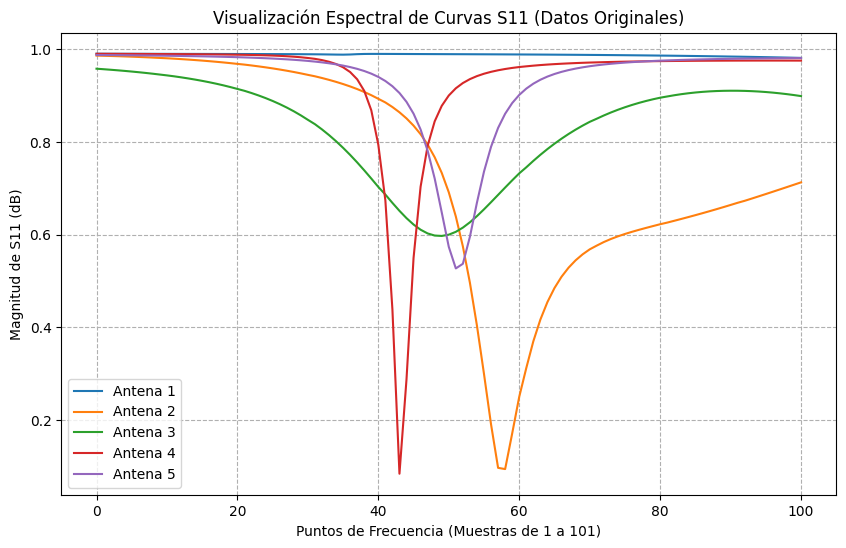

¡Gráfica generada! Cada línea representa cómo responde una antena diferente en el espectro de frecuencias.


In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar las curvas S11 originales y sus parámetros físicos
with h5py.File('train_test_split_S11.h5', 'r') as f:
    X_train_original = np.array(f['S11_combine_train'])        # (138249, 101)
    y_train_params = np.array(f['final_params_combine_train'])  # (138249, 8)

# 2. Graficar las primeras 5 curvas S11 para entender su comportamiento espectral
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(X_train_original[i], label=f'Antena {i+1}')

plt.title('Visualización Espectral de Curvas S11 (Datos Originales)')
plt.xlabel('Puntos de Frecuencia (Muestras de 1 a 101)')
plt.ylabel('Magnitud de S11 (dB)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

print("¡Gráfica generada! Cada línea representa cómo responde una antena diferente en el espectro de frecuencias.")

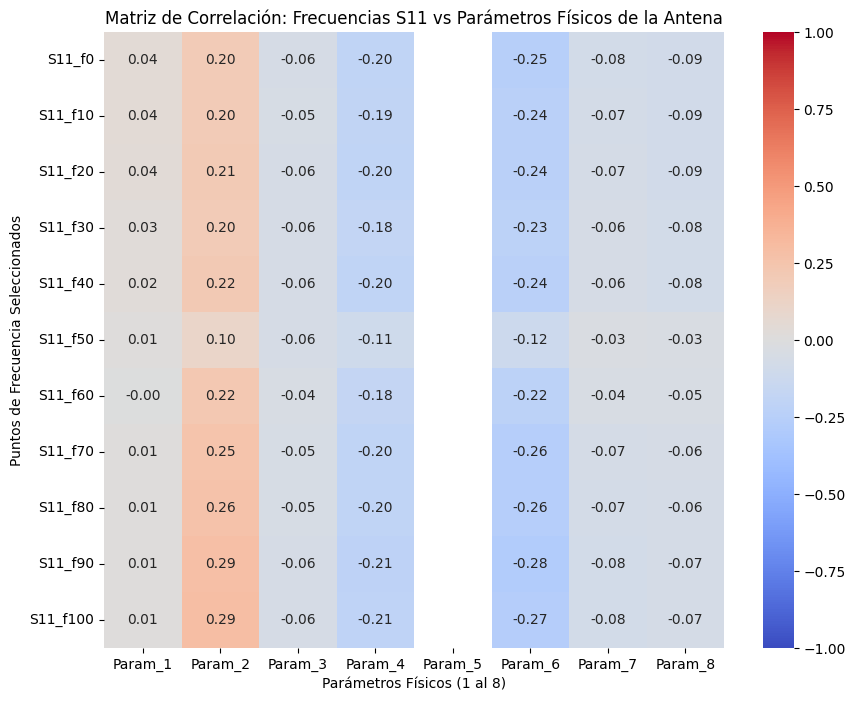

¡Matriz de correlación generada exitosamente!


In [7]:
import pandas as pd
import seaborn as sns

# 1. Para simplificar el análisis, tomaremos los 8 parámetros físicos
# y un subconjunto de puntos de la curva S11 (por ejemplo, cada 10 puntos de frecuencia)
puntos_s11_clave = X_train_original[:, ::10] # Toma las columnas 0, 10, 20... hasta 100 (11 puntos)

# 2. Crear un DataFrame de Pandas combinando estos puntos con los 8 parámetros físicos
columnas_s11 = [f'S11_f{i}' for i in range(0, 101, 10)]
columnas_params = [f'Param_{i+1}' for i in range(8)]

df_analisis = pd.DataFrame(
    data=np.hstack((puntos_s11_clave, y_train_params)),
    columns=columnas_s11 + columnas_params
)

# 3. Calcular la matriz de correlación de Pearson
matriz_corr = df_analisis.corr()

# 4. Extraer solo la relación entre las frecuencias de S11 y los parámetros físicos
corr_recortada = matriz_corr.loc[columnas_s11, columnas_params]

# 5. Graficar el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_recortada, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Frecuencias S11 vs Parámetros Físicos de la Antena')
plt.ylabel('Puntos de Frecuencia Seleccionados')
plt.xlabel('Parámetros Físicos (1 al 8)')
plt.show()

print("¡Matriz de correlación generada exitosamente!")


In [8]:
import h5py
import numpy as np

# 1. Cargar datos del archivo original S11
with h5py.File('train_test_split_S11.h5', 'r') as f:
    X_train_orig = np.array(f['S11_combine_train'])       # (138249, 101)
    X_test_orig = np.array(f['S11_combine_test'])         # (59250, 101)
    y_train = np.array(f['final_params_combine_train'])   # (138249, 8)
    y_test = np.array(f['final_params_combine_test'])     # (59250, 8)

# 2. Cargar datos del archivo S11 Codificado (17 dimensiones)
with h5py.File('train_test_split_S11encode_17d_sortf.h5', 'r') as f:
    X_train_enc = np.array(f['S11_encode_train'])         # (138249, 17)
    X_test_enc = np.array(f['S11_encode_test'])           # (59250, 17)

print("✅ Todos los conjuntos cargados con éxito.")
print(f"Set Original - Train: {X_train_orig.shape}, Test: {X_test_orig.shape}")
print(f"Set Codificado - Train: {X_train_enc.shape}, Test: {X_test_enc.shape}")
print(f"Parámetros de Salida - Train: {y_train.shape}, Test: {y_test.shape}")

✅ Todos los conjuntos cargados con éxito.
Set Original - Train: (138249, 101), Test: (59250, 101)
Set Codificado - Train: (138249, 17), Test: (59250, 17)
Parámetros de Salida - Train: (138249, 8), Test: (59250, 8)


In [9]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definir la arquitectura para 101 entradas
model_orig = Sequential([
    Dense(128, activation='relu', input_shape=(101,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(8, activation='linear') # Salida de 8 parámetros físicos
])

model_orig.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 2. Entrenar el modelo (usamos pocas epochs para velocidad, puedes subirlo a 15 o 20)
print("🚀 Entrenando Modelo 1 (Datos Originales - 101d)...")
history_orig = model_orig.fit(
    X_train_orig, y_train,
    validation_split=0.2, # Validación interna sin mezclar test
    epochs=10,
    batch_size=256,
    verbose=1
)

# 3. Medir tiempo de inferencia y predecir sobre el conjunto Test
start_time = time.time()
preds_orig = model_orig.predict(X_test_orig)
inference_time_orig = time.time() - start_time

# 4. Calcular métricas en Test
mse_orig = mean_squared_error(y_test, preds_orig)
r2_orig = r2_score(y_test, preds_orig) # Usado frecuentemente como métrica de precisión

print("\n📊 --- RESULTADOS MODELO ORIGINAL (101d) ---")
print(f"Error Cuadrático Medio (MSE): {mse_orig:.6f}")
print(f"Precisión (R² Score): {r2_orig:.4f}")
print(f"Tiempo de inferencia total: {inference_time_orig:.4f} segundos")

c:\Users\User\Desktop\ANTENAS\TRABAJO_01\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🚀 Entrenando Modelo 1 (Datos Originales - 101d)...
Epoch 1/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 237.2534 - mae: 6.4663 - val_loss: 234.2464 - val_mae: 6.1315
Epoch 2/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 219.3649 - mae: 6.0210 - val_loss: 231.9510 - val_mae: 6.1792
Epoch 3/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 216.9625 - mae: 6.0119 - val_loss: 235.9461 - val_mae: 6.7391
Epoch 4/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 214.3310 - mae: 5.9670 - val_loss: 228.0467 - val_mae: 5.9613
Epoch 5/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 212.8998 - mae: 5.9431 - val_loss: 226.4783 - val_mae: 6.2262
Epoch 6/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 212.4921 - mae: 5.9366 - val_loss: 226.6850 - val_mae: 5.9587
Epoch 7/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 212.1184 - mae: 5.9308 - val_loss: 226.4066 - val_mae: 6.2759
Epoch 8/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 211.7038 - mae: 5.9250 - val_los

In [10]:
# 1. Definir la arquitectura para 17 entradas
model_enc = Sequential([
    Dense(128, activation='relu', input_shape=(17,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(8, activation='linear') # Salida de 8 parámetros físicos
])

model_enc.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 2. Entrenar el modelo
print("🚀 Entrenando Modelo 2 (Datos Codificados - 17d)...")
history_enc = model_enc.fit(
    X_train_enc, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    verbose=1
)

# 3. Medir tiempo de inferencia y predecir sobre el conjunto Test
start_time = time.time()
preds_enc = model_enc.predict(X_test_enc)
inference_time_enc = time.time() - start_time

# 4. Calcular métricas en Test
mse_enc = mean_squared_error(y_test, preds_enc)
r2_enc = r2_score(y_test, preds_enc)

print("\n📊 --- RESULTADOS MODELO CODIFICADO (17d) ---")
print(f"Error Cuadrático Medio (MSE): {mse_enc:.6f}")
print(f"Precisión (R² Score): {r2_enc:.4f}")
print(f"Tiempo de inferencia total: {inference_time_enc:.4f} segundos")

🚀 Entrenando Modelo 2 (Datos Codificados - 17d)...
Epoch 1/10


c:\Users\User\Desktop\ANTENAS\TRABAJO_01\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 159.9988 - mae: 4.6165 - val_loss: 40.8317 - val_mae: 2.5314
Epoch 2/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 30.6145 - mae: 2.2491 - val_loss: 33.6596 - val_mae: 2.3005
Epoch 3/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 27.9088 - mae: 2.1501 - val_loss: 34.8932 - val_mae: 2.5229
Epoch 4/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 26.4854 - mae: 2.1046 - val_loss: 30.9182 - val_mae: 2.2416
Epoch 5/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 25.2279 - mae: 2.0588 - val_loss: 32.8597 - val_mae: 2.4000
Epoch 6/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 24.4367 - mae: 2.0339 - val_loss: 32.2841 - val_mae: 2.3595
Epoch 7/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 24.8769 - mae: 2.0292 - val_loss: 28.1145 - val_mae: 2.1291
Epoch 8/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 22.9266 - mae: 1.9715 - val_loss: 27.8577 - val_mae: 2.1273
Epoch 9/10
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/

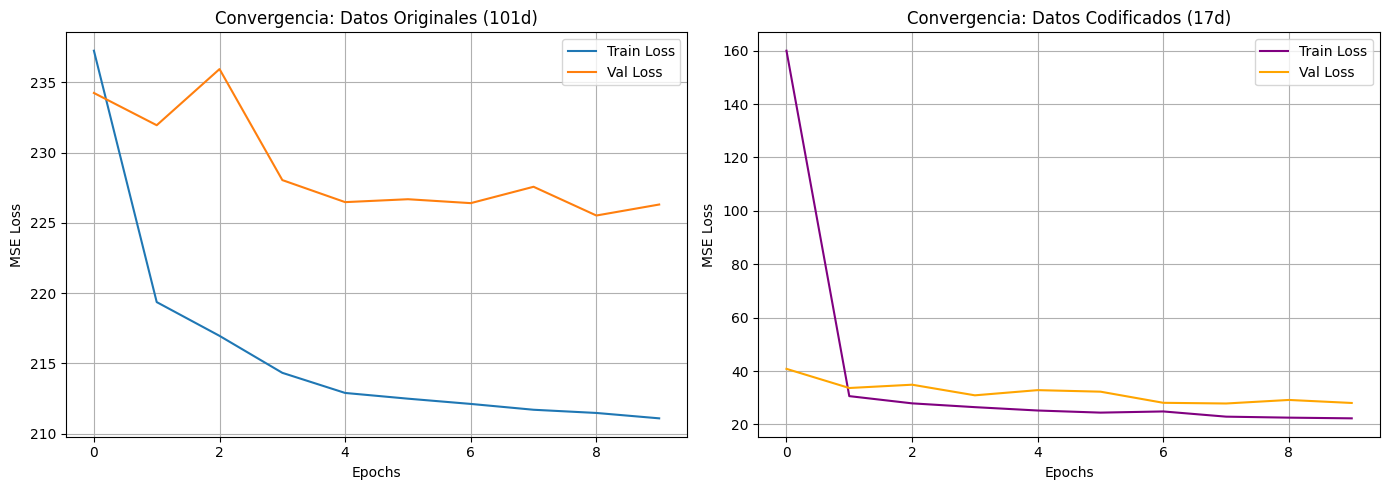

In [11]:
plt.figure(figsize=(14, 5))

# Gráfica de convergencia - Modelo Original
plt.subplot(1, 2, 1)
plt.plot(history_orig.history['loss'], label='Train Loss')
plt.plot(history_orig.history['val_loss'], label='Val Loss')
plt.title('Convergencia: Datos Originales (101d)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# Gráfica de convergencia - Modelo Codificado
plt.subplot(1, 2, 2)
plt.plot(history_enc.history['loss'], label='Train Loss', color='purple')
plt.plot(history_enc.history['val_loss'], label='Val Loss', color='orange')
plt.title('Convergencia: Datos Codificados (17d)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()